In [1]:
from datetime import datetime
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from Baselines.baselines import SeasonalAverage
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
import joblib

# Verde River Flow Final Models

In [2]:
df = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
season_length = 12
test_size = int(8.5 * season_length) # Set aside the last 8.5 years as our ultimate testing set.
df_train = df[:-test_size]
df_test = df[-test_size:]

## Verde River Downstream Flow

Our final selected model for the Verde River downstream flow is XGBoost with max_depth=6 and n_estimators=100. Features are:

* **`Temp_Verde`** — Mean temperature for the Verde River watershed (°C).
* **`Precip_Verde`** — Total precipitation for the Verde River watershed (mm).
* **`Temp_Maricopa`** — Mean temperature for Maricopa County (°C).
* **`Precip_Maricopa`** — Total precipitation for Maricopa County (mm).
* **`Population`** — Maricopa County population size.
* **`IrrigatedLand_Acres`** — Total active agricultural irrigated farmland acreage in Maricopa County.
* **`datacenters_TotalMW`** — Total accumulated power capacity allocations (Megawatts) of active data centers in Maricopa County.
* **`datacenters_TotalNum`** — Total number of operational data centers in Maricopa County.
* **`log_flow_verde_upstream`** — Log-transformed Verde upstream flow.
* **`log_flow_verde_downstream_lag_5`** — Log-transformed Verde downstream flow lagged back by 5 months.
* **`log_flow_verde_downstream_lag_6`** — Log-transformed Verde downstream flow volume lagged back by 6 months.

First we fit the model on the training data and save it as [verde_downstream_model.joblib](../Output/verde_downstream_model.joblib).

In [4]:
# ==========================================
# 1. FEATURE & LAG CONFIGURATION
# ==========================================
verde_downstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_verde_upstream",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6"
]

verde_lags = [
    "log_flow_verde_downstream_lag_1",
    "log_flow_verde_downstream_lag_2",
    "log_flow_verde_downstream_lag_3",
    "log_flow_verde_downstream_lag_4",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6",
    "log_flow_verde_downstream_lag_7",
    "log_flow_verde_downstream_lag_8",
    "log_flow_verde_downstream_lag_9",
    "log_flow_verde_downstream_lag_10",
    "log_flow_verde_downstream_lag_11",
    "log_flow_verde_downstream_lag_12"
]

# ==========================================
# 2. DATA CLEANING & TARGET ISOLATION
# ==========================================
target = "log_flow_verde_downstream"
all_cols_needed = verde_downstream_features + verde_lags + [target]
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

# ==========================================
# 3. MODEL INITIALIZATION & TRAINING
# ==========================================
verde_downstream_model = XGBRegressor(max_depth=6, n_estimators=100)

verde_downstream_model.fit(df_model_train[verde_downstream_features], df_model_train[target])

print("Model trained successfully on the historical data matrix!")
print()

# Save the final trained model
joblib.dump(verde_downstream_model, '../Output/verde_downstream_model.joblib')

# To load it back later:
# loaded_model = joblib.load('../Output/verde_downstream_model.joblib')

Model trained successfully on the historical data matrix!



['../Output/verde_downstream_model.joblib']

Now we look at feature importances for the trained model.

In [4]:
# ==========================================
# 1. MODEL IMPORTANCES
# ==========================================

print("Model feature importances:")
model_importances = {v: float(verde_downstream_model.feature_importances_[i]) for (i,v) in enumerate(verde_downstream_features)}
sorted_model_importances = dict(sorted(model_importances.items(), key= lambda item: item[1], reverse=True))

sorted_model_importances

Model feature importances:


{'log_flow_verde_upstream': 0.29463768005371094,
 'IrrigatedLand_Acres': 0.17727959156036377,
 'Population': 0.11378706246614456,
 'log_flow_verde_downstream_lag_5': 0.08568409830331802,
 'Precip_Maricopa': 0.07908855378627777,
 'Temp_Maricopa': 0.07833734154701233,
 'log_flow_verde_downstream_lag_6': 0.07410061359405518,
 'Precip_Verde': 0.050305310636758804,
 'Temp_Verde': 0.04618663713335991,
 'datacenters_TotalMW': 0.0005930206971243024,
 'datacenters_TotalNum': 0.0}

Plotting feature importance.

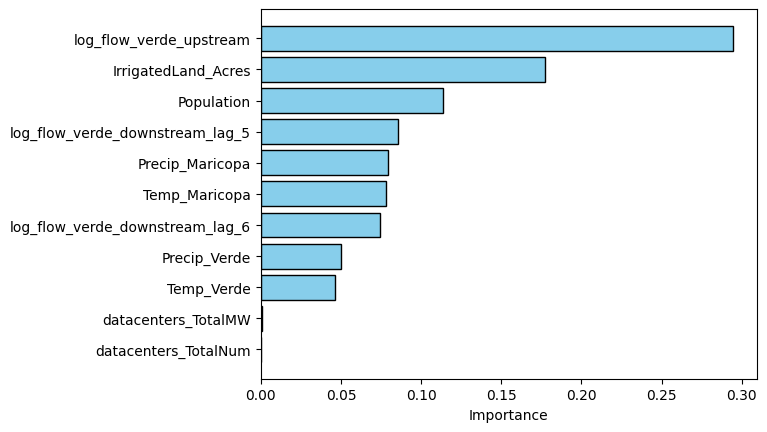

In [5]:
feature_importance_VerdeDownstream = pd.DataFrame({
    "Feature":verde_downstream_features,
    "Importance":verde_downstream_model.feature_importances_
}).sort_values("Importance")


plt.barh(feature_importance_VerdeDownstream.Feature, feature_importance_VerdeDownstream.Importance,
         edgecolor="black", color="skyblue")
plt.xlabel("Importance")

plt.savefig(
    "../Output/FeatureImportance_VerdeDownstream.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Generating parital dependence plots.

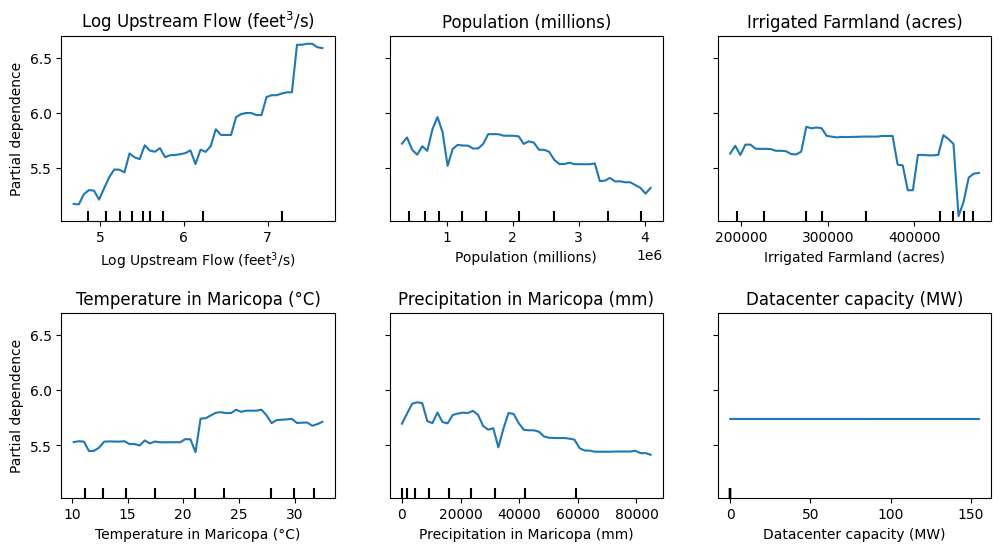

In [6]:
#features to plot 
features_of_interest = [
    "log_flow_verde_upstream",
    "Population",
    "IrrigatedLand_Acres",
     "Temp_Maricopa",
    "Precip_Maricopa",
    "datacenters_TotalMW"]

#custom titles for each subplot
feature_names = [
     "Log Upstream Flow (feet$^3$/s)",
     "Population (millions)",
     "Irrigated Farmland (acres)",
    "Temperature in Maricopa (°C)",
    "Precipitation in Maricopa (mm)",
    "Datacenter capacity (MW)"]


fig, ax = plt.subplots(figsize=(12, 6))
fig.subplots_adjust(hspace=0.5)

#plotting partial dependencies
display = PartialDependenceDisplay.from_estimator(
    estimator=verde_downstream_model,
    X=df_model_train[verde_downstream_features],
    features=features_of_interest,
    ax=ax,
    grid_resolution=50)

for ax, title in zip(display.axes_.ravel(), feature_names):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(title, fontsize=10)

#exporting to png
plt.savefig(
    "../Output/PartialDependency_VerdeDownstream.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Now we evaluate the final selected model on the test set.

Running walk-forward cross-validation...
Predictions complete!

       VERDE RIVER DOWNSTREAM PERFORMANCE EVALUATION       
FORECAST METHOD              | RMSE         | % OF MEAN FLOW 
-----------------------------------------------------------------
Seasonal Average (Baseline)  | 0.7500       | 13.47         %
XGBoost Regressor (Model)    | 0.6056       | 10.88         %
-----------------------------------------------------------------
 Average Log Outflow: 5.5675
 Conclusion: XGBoost reduces forecast error by 19.25%



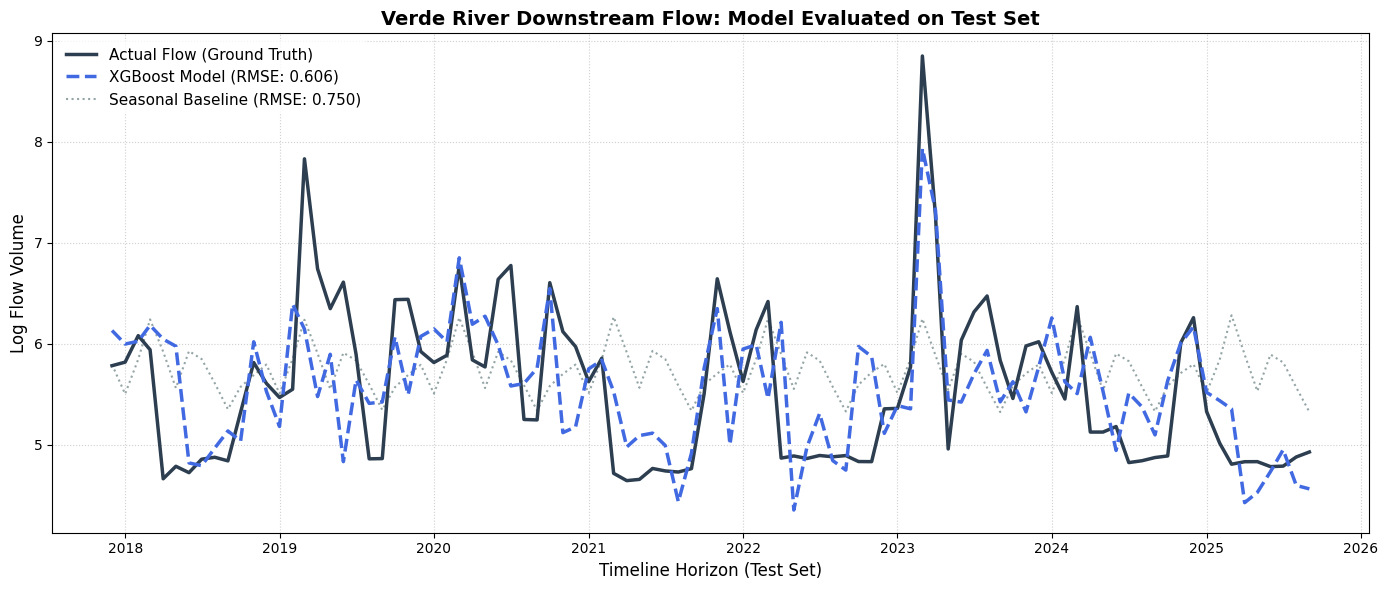

In [8]:
# ==========================================
# 1. FEATURE & LAG CONFIGURATION
# ==========================================
verde_downstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_verde_upstream",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6"
]

verde_lags = [
    "log_flow_verde_downstream_lag_1",
    "log_flow_verde_downstream_lag_2",
    "log_flow_verde_downstream_lag_3",
    "log_flow_verde_downstream_lag_4",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6",
    "log_flow_verde_downstream_lag_7",
    "log_flow_verde_downstream_lag_8",
    "log_flow_verde_downstream_lag_9",
    "log_flow_verde_downstream_lag_10",
    "log_flow_verde_downstream_lag_11",
    "log_flow_verde_downstream_lag_12"
]

# ==========================================
# 2. DATA CLEANING & TARGET ISOLATION
# ==========================================

target = "log_flow_verde_downstream"
all_cols_needed = verde_downstream_features + verde_lags + [target]
df_model_test = df_test.dropna(subset=all_cols_needed).reset_index(drop=True)
df_model_full = df.dropna(subset=all_cols_needed).reset_index(drop=True)

# ==========================================
# 3. MODEL INITIALIZATION
# ==========================================

season_length = 12

verde_downstream_model_untrained = XGBRegressor(max_depth=6, n_estimators=100)
baseline_model = SeasonalAverage(season_length=season_length)

verde_downstream_preds = []
baseline_preds = []

# ==========================================
# 4. GENERATE PREDICTIONS FOR THE TEST SET
# ==========================================

train_data_len = len(df_model_full)-len(df_model_test)

print("Running walk-forward cross-validation...")

for i in range(len(df_model_test)):
    X_tt = df_model_full[verde_downstream_features].iloc[:train_data_len+i]
    X_ho = df_model_full[verde_downstream_features].iloc[[train_data_len+i]]

    y_tt = df_model_full[target].iloc[:train_data_len+i]

    verde_downstream_model_untrained.fit(X_tt,y_tt)
    verde_downstream_preds.append(verde_downstream_model_untrained.predict(X_ho)[0])

    baseline_model.fit(y_tt)
    baseline_preds.append(baseline_model.forecast(1))

print("Predictions complete!")

# ==========================================
# 5. CALCULATE RMSE
# ==========================================

y_ho = df_model_test[target]
mean_actual_flow = np.mean(y_ho)

verde_downstream_rmse = root_mean_squared_error(y_ho,verde_downstream_preds)
baseline_rmse = root_mean_squared_error(y_ho,baseline_preds)

# Calculate error percentages (NRMSE)
model_pct = (verde_downstream_rmse / mean_actual_flow) * 100
baseline_pct = (baseline_rmse / mean_actual_flow) * 100

# Calculate raw error improvement percentage
pct_improvement = ((baseline_rmse - verde_downstream_rmse) / baseline_rmse) * 100

# ==========================================
# 6 PRINT AND SAVE RESULTS
# ==========================================


print("\n" + "="*65)
print("       VERDE RIVER DOWNSTREAM PERFORMANCE EVALUATION       ")
print("="*65)
print(f"{'FORECAST METHOD':<28} | {'RMSE':<12} | {'% OF MEAN FLOW':<15}")
print("-"*65)
print(f"{'Seasonal Average (Baseline)':<28} | {baseline_rmse:<12.4f} | {baseline_pct:<14.2f}%")
print(f"{'XGBoost Regressor (Model)':<28} | {verde_downstream_rmse:<12.4f} | {model_pct:<14.2f}%")
print("-"*65)
print(f" Average Log Outflow: {mean_actual_flow:.4f}")
print(f" Conclusion: XGBoost reduces forecast error by {pct_improvement:.2f}%")
print("="*65 + "\n")

# 1. Prepare table cell matrix and headers
table_data = [
    ["Seasonal Average (Baseline)", f"{baseline_rmse:.4f}", f"{baseline_pct:.2f}%"],
    ["XGBoost Regressor (Model)", f"{verde_downstream_rmse:.4f}", f"{model_pct:.2f}%"]
]
column_headers = ["FORECAST METHOD", "RMSE", "% OF MEAN FLOW"]

# Define custom column widths (55% for method names, 20% and 25% for numbers)
custom_column_widths = [0.55, 0.20, 0.25]

# 2. Setup blank axis figure container for the table block
fig, ax = plt.subplots(figsize=(9, 2.5), dpi=300)
ax.axis("off")  # Completely hide chart grid borders and ticks

# 3. Create the table canvas structure (defaulting to left alignment)
perf_table = ax.table(
    cellText=table_data, 
    colLabels=column_headers, 
    colWidths=custom_column_widths, 
    loc="center", 
    cellLoc="left"
)

# 4. Styling properties (Fonts, sizing, and padding structural elements)
perf_table.auto_set_font_size(False)
perf_table.set_fontsize(11)
perf_table.scale(1.0, 1.8) # Adjust horizontal scale since colWidths handles width now

# --- CUSTOM COLUMN ALIGNMENTS & HEADER STYLING ---
# Total rows = len(table_data) + 1 (the header row is index 0)
for row_idx in range(len(table_data) + 1):
    for col_idx in range(len(column_headers)):
        cell = perf_table[row_idx, col_idx]
        
        # Style the header row (row 0)
        if row_idx == 0:
            cell.get_text().set_weight('bold')
            cell.set_facecolor('#f2f2f2')
            
        # Center align columns 1 and 2 (RMSE and % of Mean Flow) for both headers and data
        if col_idx in [1, 2]:
            cell.get_text().set_horizontalalignment('center')

# Add summary metrics below the table box frame
plt.text(0.05, 0.1, f"Average Log Outflow: {mean_actual_flow:.4f}", fontsize=10, transform=ax.transAxes)
plt.text(0.05, -0.05, f"Conclusion: XGBoost reduces forecast RMSE by {pct_improvement:.2f}%", 
         fontsize=10, fontweight='bold', color='royalblue', transform=ax.transAxes)

# 5. Export clean table element image artifact
plt.savefig(
    "../Output/verde_downstream_performance_table.png", 
    dpi=300, 
    bbox_inches="tight"
)
plt.close() # Clean workspace memory


# ==========================================
# 7. PLOTTING RESULTS
# ==========================================

plot_actuals = y_ho
plot_model_preds = verde_downstream_preds
plot_baseline_preds = baseline_preds
ylabel_text = "Log Flow Volume"

plt.figure(figsize=(14, 6))

# Align the x-axis timeline using the test set dates
test_dates = pd.to_datetime(df_model_test["Time"])

# Plot 1: Ground Truth Actual Data
plt.plot(
    test_dates, plot_actuals, 
    label="Actual Flow (Ground Truth)", 
    color="#2c3e50", linewidth=2.5, zorder=2
)

# Plot 2: XGBoost Model Predictions
plt.plot(
    test_dates, plot_model_preds, 
    label=f"XGBoost Model (RMSE: {verde_downstream_rmse:.3f})", 
    color="royalblue", linestyle="--", linewidth=2.5, zorder=3
)

# Plot 3: Seasonal Baseline Predictions
plt.plot(
    test_dates, plot_baseline_preds, 
    label=f"Seasonal Baseline (RMSE: {baseline_rmse:.3f})", 
    color="#95a5a6", linestyle=":", linewidth=1.5, zorder=1
)

# Formatting and Styling
plt.title("Verde River Downstream Flow: Model Evaluated on Test Set", fontsize=14, fontweight='bold')
plt.xlabel("Timeline Horizon (Test Set)", fontsize=12)
plt.ylabel(ylabel_text, fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left", fontsize=11, frameon=True, facecolor="white", edgecolor="none")
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# Optimize layout structure and render
plt.tight_layout()

# Save plot as png
plt.savefig(
    "../Output/verde_downstream_model_evaluation.png", 
    dpi=300, 
    bbox_inches="tight"
)


plt.show()

## Verde River Upstream Flow

Our final selected model for the Verde River upstream flow is Gradient Boost with max_depth=3 and n_estimators=100. Features are:

* **`Temp_Verde`** — Mean temperature for the Verde River watershed (°C).
* **`Precip_Verde`** — Total precipitation for the Verde River watershed (mm).
* **`log_flow_verde_upstream_lag_1`** — Log-transformed Verde upstream flow lagged back by 1 month.
* **`log_flow_verde_upstream_lag_11`** — Log-transformed Verde upstream flow volume lagged back by 11 months.

First we fit the model on the training data and save it as [verde_upstream_model.joblib](../Output/verde_upstream_model.joblib).

In [8]:
# ==========================================
# 1. FEATURE & LAG CONFIGURATION
# ==========================================
verde_upstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_11"
]

verde_upstream_lags = [
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_2",
    "log_flow_verde_upstream_lag_3",
    "log_flow_verde_upstream_lag_4",
    "log_flow_verde_upstream_lag_5",
    "log_flow_verde_upstream_lag_6",
    "log_flow_verde_upstream_lag_7",
    "log_flow_verde_upstream_lag_8",
    "log_flow_verde_upstream_lag_9",
    "log_flow_verde_upstream_lag_10",
    "log_flow_verde_upstream_lag_11",
    "log_flow_verde_upstream_lag_12"
]

# ==========================================
# 2. DATA CLEANING & TARGET ISOLATION
# ==========================================
target = "log_flow_verde_upstream"
all_cols_needed = verde_upstream_features + verde_upstream_lags + [target]
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

# ==========================================
# 3. MODEL INITIALIZATION & TRAINING
# ==========================================
verde_upstream_model = GradientBoostingRegressor(max_depth=3, n_estimators=100)

verde_upstream_model.fit(df_model_train[verde_upstream_features], df_model_train[target])

print("Model trained successfully on the historical data matrix!")
print()

# Save the final trained model
joblib.dump(verde_upstream_model, '../Output/verde_upstream_model.joblib')

# To load it back later:
# loaded_model = joblib.load('../Output/verde_upstream_model.joblib')

Model trained successfully on the historical data matrix!



['../Output/verde_upstream_model.joblib']

Now we look at feature importances for the trained model.

In [9]:
# ==========================================
# 1. MODEL IMPORTANCES
# ==========================================

print("Model feature importances:")
model_importances = {v: float(verde_upstream_model.feature_importances_[i]) for (i,v) in enumerate(verde_upstream_features)}
sorted_model_importances = dict(sorted(model_importances.items(), key= lambda item: item[1], reverse=True))

sorted_model_importances

Model feature importances:


{'log_flow_verde_upstream_lag_1': 0.3348717370008917,
 'Precip_Verde': 0.32883356930773605,
 'Temp_Verde': 0.3027227792985189,
 'log_flow_verde_upstream_lag_11': 0.033571914392853376}

Plotting feature importance.

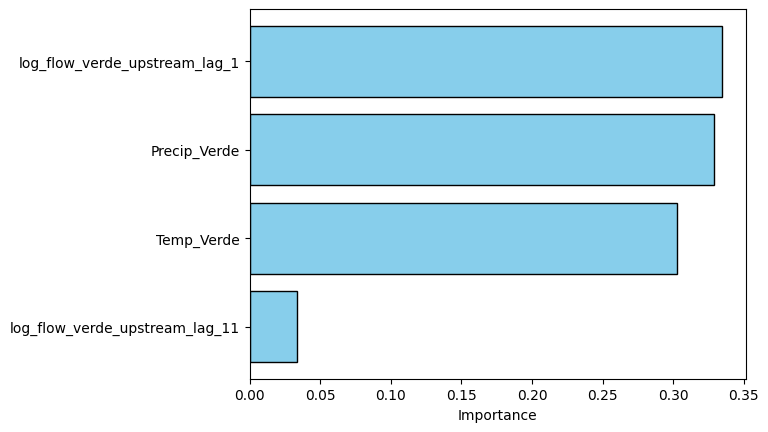

In [10]:
feature_importance_VerdeUpstream = pd.DataFrame({
    "Feature":verde_upstream_features,
    "Importance":verde_upstream_model.feature_importances_
}).sort_values("Importance")


plt.barh(feature_importance_VerdeUpstream.Feature, feature_importance_VerdeUpstream.Importance,
         edgecolor="black", color="skyblue")
plt.xlabel("Importance")

plt.savefig(
    "../Output/FeatureImportance_VerdeUpstream.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Generating partial dependence plots.

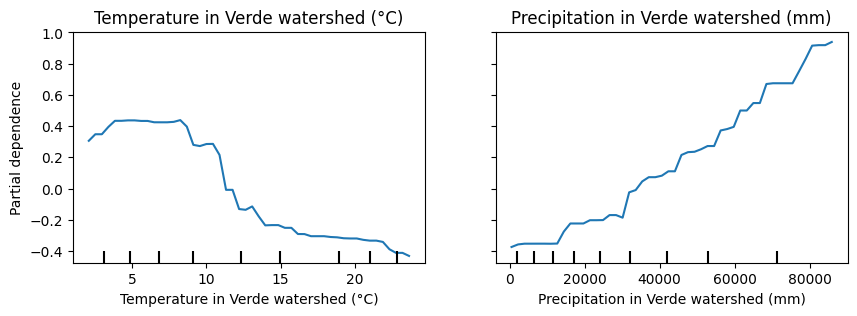

In [11]:
#features to plot 
features_of_interest = [
     "Temp_Verde",
    "Precip_Verde"]

#custom titles for each subplot
feature_names = [
    "Temperature in Verde watershed (°C)",
    "Precipitation in Verde watershed (mm)"]


fig, ax = plt.subplots(figsize=(10, 3))
fig.subplots_adjust(hspace=0.5)

#plotting partial dependencies
display = PartialDependenceDisplay.from_estimator(
    estimator=verde_upstream_model,
    X=df_model_train[verde_upstream_features],
    features=features_of_interest,
    ax=ax,
    grid_resolution=50)

for ax, title in zip(display.axes_.ravel(), feature_names):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(title, fontsize=10)

#exporting to png
plt.savefig(
    "../Output/PartialDependency_VerdeUpstream.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Now we evaluate the final selected model on the test data set.

Running walk-forward cross-validation...
Predictions complete!

       VERDE RIVER UPSTREAM PERFORMANCE EVALUATION       
FORECAST METHOD              | RMSE         | % OF MEAN FLOW 
-----------------------------------------------------------------
Seasonal Average (Baseline)  | 0.7539       | 13.95         %
Gradient Boost Regressor (Model) | 0.3297       | 6.10          %
-----------------------------------------------------------------
 Average Log Outflow: 5.4031
 Conclusion: Gradient boost reduces forecast error by 56.26%



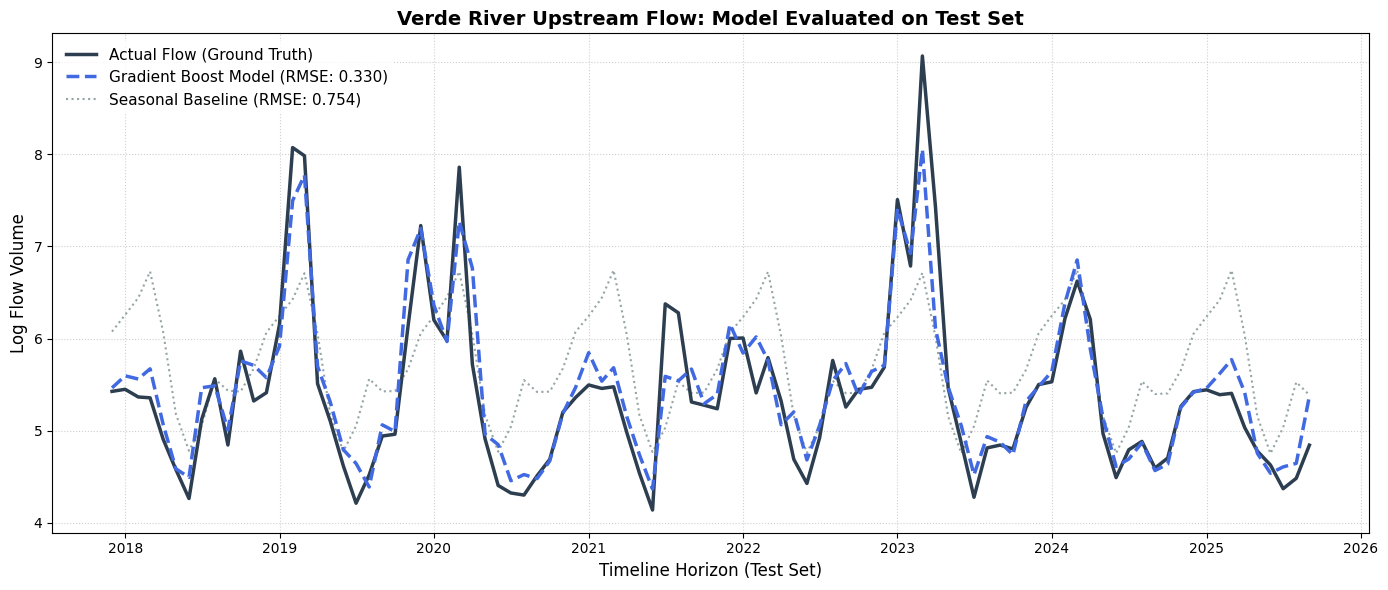

In [11]:
# ==========================================
# 1. FEATURE & LAG CONFIGURATION
# ==========================================
verde_upstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_11"
]

verde_upstream_lags = [
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_2",
    "log_flow_verde_upstream_lag_3",
    "log_flow_verde_upstream_lag_4",
    "log_flow_verde_upstream_lag_5",
    "log_flow_verde_upstream_lag_6",
    "log_flow_verde_upstream_lag_7",
    "log_flow_verde_upstream_lag_8",
    "log_flow_verde_upstream_lag_9",
    "log_flow_verde_upstream_lag_10",
    "log_flow_verde_upstream_lag_11",
    "log_flow_verde_upstream_lag_12"
]

# ==========================================
# 2. DATA CLEANING & TARGET ISOLATION
# ==========================================

target = "log_flow_verde_upstream"
all_cols_needed = verde_upstream_features + verde_upstream_lags + [target]
df_model_test = df_test.dropna(subset=all_cols_needed).reset_index(drop=True)
df_model_full = df.dropna(subset=all_cols_needed).reset_index(drop=True)

# ==========================================
# 3. MODEL INITIALIZATION
# ==========================================

season_length = 12

verde_upstream_model_untrained = GradientBoostingRegressor(max_depth=3, n_estimators=100)
baseline_model = SeasonalAverage(season_length=season_length)

verde_upstream_preds = []
baseline_preds = []

# ==========================================
# 4. GENERATE PREDICTIONS FOR THE TEST SET
# ==========================================

train_data_len = len(df_model_full)-len(df_model_test)

print("Running walk-forward cross-validation...")

for i in range(len(df_model_test)):
    X_tt = df_model_full[verde_upstream_features].iloc[:train_data_len+i]
    X_ho = df_model_full[verde_upstream_features].iloc[[train_data_len+i]]

    y_tt = df_model_full[target].iloc[:train_data_len+i]

    verde_upstream_model_untrained.fit(X_tt,y_tt)
    verde_upstream_preds.append(verde_upstream_model_untrained.predict(X_ho)[0])

    baseline_model.fit(y_tt)
    baseline_preds.append(baseline_model.forecast(1))

print("Predictions complete!")

# ==========================================
# 5. CALCULATE RMSE
# ==========================================

y_ho = df_model_test[target]
mean_actual_flow = np.mean(y_ho)

verde_upstream_rmse = root_mean_squared_error(y_ho,verde_upstream_preds)
baseline_rmse = root_mean_squared_error(y_ho,baseline_preds)

# Calculate error percentages (NRMSE)
model_pct = (verde_upstream_rmse / mean_actual_flow) * 100
baseline_pct = (baseline_rmse / mean_actual_flow) * 100

# Calculate raw error improvement percentage
pct_improvement = ((baseline_rmse - verde_upstream_rmse) / baseline_rmse) * 100

# ==========================================
# 6. PRINT AND SAVE RESULTS
# ==========================================


print("\n" + "="*65)
print("       VERDE RIVER UPSTREAM PERFORMANCE EVALUATION       ")
print("="*65)
print(f"{'FORECAST METHOD':<28} | {'RMSE':<12} | {'% OF MEAN FLOW':<15}")
print("-"*65)
print(f"{'Seasonal Average (Baseline)':<28} | {baseline_rmse:<12.4f} | {baseline_pct:<14.2f}%")
print(f"{'Gradient Boost Regressor (Model)':<28} | {verde_upstream_rmse:<12.4f} | {model_pct:<14.2f}%")
print("-"*65)
print(f" Average Log Outflow: {mean_actual_flow:.4f}")
print(f" Conclusion: Gradient boost reduces forecast error by {pct_improvement:.2f}%")
print("="*65 + "\n")


# 1. Prepare table cell matrix and headers
table_data = [
    ["Seasonal Average (Baseline)", f"{baseline_rmse:.4f}", f"{baseline_pct:.2f}%"],
    ["Gradient Boost Regressor (Model)", f"{verde_upstream_rmse:.4f}", f"{model_pct:.2f}%"]
]
column_headers = ["FORECAST METHOD", "RMSE", "% OF MEAN FLOW"]

# Define custom column widths (55% for method names, 20% and 25% for numbers)
custom_column_widths = [0.55, 0.20, 0.25]

# 2. Setup blank axis figure container for the table block
fig, ax = plt.subplots(figsize=(9, 2.5), dpi=300)
ax.axis("off")  # Completely hide chart grid borders and ticks

# 3. Create the table canvas structure (defaulting to left alignment)
perf_table = ax.table(
    cellText=table_data, 
    colLabels=column_headers, 
    colWidths=custom_column_widths, 
    loc="center", 
    cellLoc="left"
)

# 4. Styling properties (Fonts, sizing, and padding structural elements)
perf_table.auto_set_font_size(False)
perf_table.set_fontsize(11)
perf_table.scale(1.0, 1.8) # Adjust horizontal scale since colWidths handles width now

# --- CUSTOM COLUMN ALIGNMENTS & HEADER STYLING ---
# Total rows = len(table_data) + 1 (the header row is index 0)
for row_idx in range(len(table_data) + 1):
    for col_idx in range(len(column_headers)):
        cell = perf_table[row_idx, col_idx]
        
        # Style the header row (row 0)
        if row_idx == 0:
            cell.get_text().set_weight('bold')
            cell.set_facecolor('#f2f2f2')
            
        # Center align columns 1 and 2 (RMSE and % of Mean Flow) for both headers and data
        if col_idx in [1, 2]:
            cell.get_text().set_horizontalalignment('center')

# Add summary metrics below the table box frame
plt.text(0.05, 0.1, f"Average Log Outflow: {mean_actual_flow:.4f}", fontsize=10, transform=ax.transAxes)
plt.text(0.05, -0.05, f"Conclusion: Gradient boost reduces forecast RMSE by {pct_improvement:.2f}%", 
         fontsize=10, fontweight='bold', color='royalblue', transform=ax.transAxes)

# 5. Export clean table element image artifact
plt.savefig(
    "../Output/verde_upstream_performance_table.png", 
    dpi=300, 
    bbox_inches="tight"
)
plt.close() # Clean workspace memory

# ==========================================
# 7. PLOTTING RESULTS
# ==========================================

plot_actuals = y_ho
plot_model_preds = verde_upstream_preds
plot_baseline_preds = baseline_preds
ylabel_text = "Log Flow Volume"

plt.figure(figsize=(14, 6))

# Align the x-axis timeline using the test set dates
test_dates = pd.to_datetime(df_model_test["Time"])

# Plot 1: Ground Truth Actual Data
plt.plot(
    test_dates, plot_actuals, 
    label="Actual Flow (Ground Truth)", 
    color="#2c3e50", linewidth=2.5, zorder=2
)

# Plot 2: Gradient Boost Model Predictions
plt.plot(
    test_dates, plot_model_preds, 
    label=f"Gradient Boost Model (RMSE: {verde_upstream_rmse:.3f})", 
    color="royalblue", linestyle="--", linewidth=2.5, zorder=3
)

# Plot 3: Seasonal Baseline Predictions
plt.plot(
    test_dates, plot_baseline_preds, 
    label=f"Seasonal Baseline (RMSE: {baseline_rmse:.3f})", 
    color="#95a5a6", linestyle=":", linewidth=1.5, zorder=1
)

# Formatting and Styling
plt.title("Verde River Upstream Flow: Model Evaluated on Test Set", fontsize=14, fontweight='bold')
plt.xlabel("Timeline Horizon (Test Set)", fontsize=12)
plt.ylabel(ylabel_text, fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left", fontsize=11, frameon=True, facecolor="white", edgecolor="none")
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# Optimize layout structure and render
plt.tight_layout()

# Save plot as png
plt.savefig(
    "../Output/verde_upstream_model_evaluation.png", 
    dpi=300, 
    bbox_inches="tight"
)

plt.show()